# Generación de paletas de colores a partir de imágenes con técnicas de machine learning no supervisado

En este notebook desarrollaremos un método para extraer los tonos dominantes de una obra de arte y
generar con ellos un muestrario de colores representativos. Utilizaremos el algoritmo KMeans sobre los
píxeles de cada imagen y la técnica t-SNE para visualizar la distribución de colores en dos
dimensiones. Estos son los pasos seguidos:

- Importar las librerías necesarias.
- Cargar y seleccionar un conjunto de imágenes de diferentes estilos artísticos.
- Preparar las imágenes mediante un pipeline de transformaciones.
- Seleccionar el número de clústeres para cada imagen.
- Generar la paleta de colores y visualizar su distribución con t-SNE.

## 1. Importación de librerías requeridas

Importaremos las librerías `numpy` y `pandas` para el manejo de los datos, `matplotlib` para las
visualizaciones y `PIL` para la carga de las imágenes. De `scikit-learn` usaremos `KMeans` para la
agrupación, las métricas de evaluación y `TSNE` para la reducción de la dimensionalidad:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE

Definiremos también los parámetros que usaremos a lo largo del notebook. Fijamos `random_state = 0`
porque tanto KMeans como t-SNE tienen componentes aleatorios y queremos que los resultados sean
reproducibles:

In [ ]:
root_path = 'Imagenes'      # carpeta con las imagenes
max_side = 200              # lado mayor de la imagen despues de redimensionar
max_pixels = 30000          # numero maximo de pixeles que entran al modelo
n_sample_metrics = 3000     # pixeles usados para calcular las metricas internas
n_sample_tsne = 2500        # pixeles que se proyectan con t-SNE
k_min, k_max = 2, 20        # rango de busqueda para el numero de clusteres
max_delta_e = 8.0           # error de color maximo admitido en la paleta
random_state = 0

np.random.seed(random_state)
plt.rcParams['figure.dpi'] = 110

## 2. Carga de datos

El conjunto de datos está formado por imágenes de obras de arte descargadas del repositorio
sugerido en el enunciado. Definiremos la función `load_image()` para la carga de cada imagen. Esta
función asume que se tiene una carpeta con las imágenes y utiliza `Image.open()` para leerlas,
convirtiéndolas siempre al modo `RGB`:

In [3]:
def load_image(path):
    """
    Retorna un arreglo de numpy con la imagen en formato RGB.

    Parametros:
    path : str
        Ruta del archivo de imagen.
    """
    img = Image.open(path)
    img = img.convert('RGB')     # nos aseguramos de tener siempre tres canales
    return np.array(img)

Definiremos la lista de archivos `img_files` recorriendo el contenido de la carpeta. Nos quedamos
solo con los archivos de imagen y los ordenamos alfabéticamente, de forma que las obras aparezcan
siempre en el mismo orden a lo largo del notebook:

In [4]:
valid_ext = ('.jpg', '.jpeg', '.png')      # extensiones de imagen que aceptamos

img_files = []
for file_name in os.listdir(root_path):    # recorremos el contenido de la carpeta
    if file_name.lower().endswith(valid_ext):
        img_files.append(file_name)

img_files = sorted(img_files)              # ordenamos para fijar siempre el mismo orden
img_files

['albrecht-altdorfer_birth-of-mary.jpg',
 'andrea-del-sarto_christ-the-redeemer.jpg',
 'camille-pissarro_pear-tress-in-bloom-eragny-morning.jpg',
 'edward-hopper_burly-cobb-hen-coop-and-barn.jpg',
 'pablo-picasso_the-corrida-1901.jpg',
 'utagawa-kuniyoshi_shimamura-danjo-takanori-riding-the-waves-on-the-backs-of-large-crabs.jpg',
 'vincent-van-gogh_the-starry-night-1889(1).jpg']

### Selección de las imágenes

Seleccionamos siete obras buscando la mayor diversidad posible de estilos artísticos. La motivación
es que cada estilo organiza el color de una forma distinta, y esto nos permitirá comprobar si el
método se adapta a cada imagen en lugar de entregar siempre el mismo resultado. Por ejemplo, esperamos
que una obra impresionista, construida con pinceladas de colores separados, necesite más grupos que
una obra renacentista pintada con una gama de colores mucho más restringida.

Los archivos del repositorio siguen el formato `pintor_titulo-de-la-obra.jpg`, así que basta con
tomar la parte anterior al guion bajo para identificar al autor. Asociaremos cada autor con su estilo
en el siguiente diccionario:

In [5]:
info_obras = {
    'albrecht-altdorfer': ('Albrecht Altdorfer', 'Renacimiento nordico'),
    'andrea-del-sarto': ('Andrea del Sarto', 'Alto Renacimiento italiano'),
    'camille-pissarro': ('Camille Pissarro', 'Impresionismo'),
    'edward-hopper': ('Edward Hopper', 'Realismo estadounidense'),
    'pablo-picasso': ('Pablo Picasso', 'Postimpresionismo'),
    'utagawa-kuniyoshi': ('Utagawa Kuniyoshi', 'Ukiyo-e (grabado japones)'),
    'vincent-van-gogh': ('Vincent van Gogh', 'Postimpresionismo'),
}


def get_info(file_name):
    """
    Retorna el autor y el estilo de una obra a partir del nombre del archivo.

    Parametros:
    file_name : str
        Nombre del archivo de imagen.
    """
    key = file_name.split('_')[0]      # el nombre del pintor va antes del guion bajo
    return info_obras.get(key, ('Sin catalogar', 'Sin catalogar'))

Cargaremos todas las imágenes y revisaremos sus dimensiones para conocer el tamaño del conjunto con
el que vamos a trabajar:

In [6]:
img_original = [load_image(os.path.join(root_path, f)) for f in img_files]

resumen_carga = pd.DataFrame({
    'archivo': img_files,
    'autor': [get_info(f)[0] for f in img_files],
    'estilo': [get_info(f)[1] for f in img_files],
    'alto': [img.shape[0] for img in img_original],
    'ancho': [img.shape[1] for img in img_original],
    'pixeles': [img.shape[0] * img.shape[1] for img in img_original],
})
resumen_carga

,archivo,autor,estilo,alto,ancho,pixeles
0,albrecht-altdorfer_birth-of-mary.jpg,Albrecht Altdorfer,Renacimiento nordico,1646,1382,2274772
1,andrea-del-sarto_christ-the-redeemer.jpg,Andrea del Sarto,Alto Renacimiento italiano,2350,1382,3247700
2,camille-pissarro_pear-tress-in-bloom-eragny-mo...,Camille Pissarro,Impresionismo,1382,1634,2258188
3,edward-hopper_burly-cobb-hen-coop-and-barn.jpg,Edward Hopper,Realismo estadounidense,1382,1936,2675552
4,pablo-picasso_the-corrida-1901.jpg,Pablo Picasso,Postimpresionismo,1382,1692,2338344
5,utagawa-kuniyoshi_shimamura-danjo-takanori-rid...,Utagawa Kuniyoshi,Ukiyo-e (grabado japones),2030,1382,2805460
6,vincent-van-gogh_the-starry-night-1889(1).jpg,Vincent van Gogh,Postimpresionismo,1382,2214,3059748


A continuación podemos visualizar las obras seleccionadas:

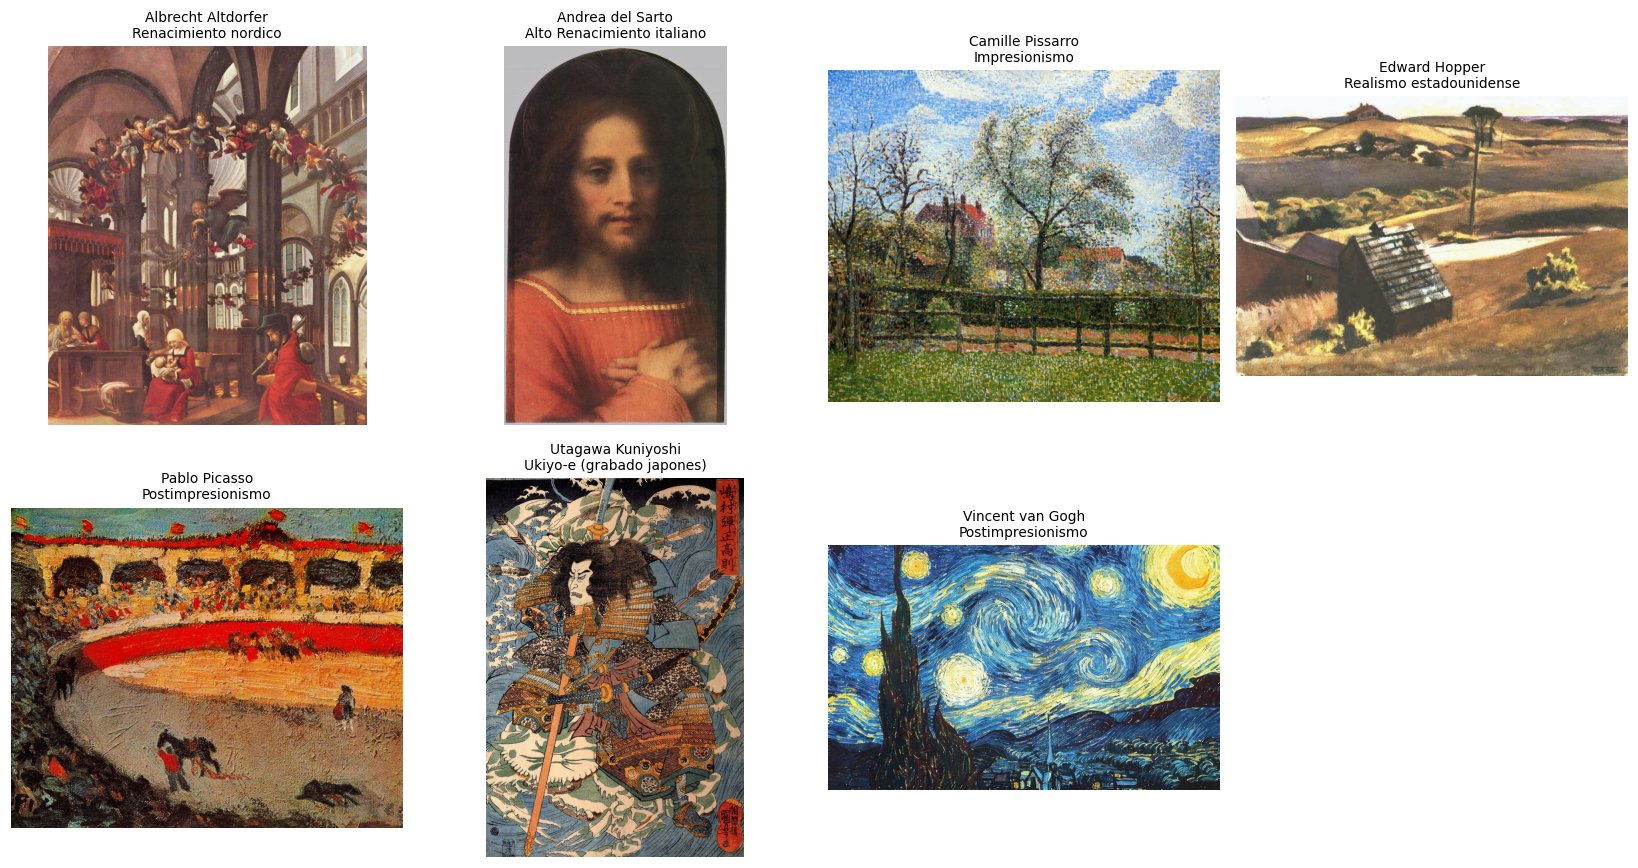

In [7]:
plt.figure(figsize=(15, 8))

for i in range(len(img_original)):
    autor, estilo = get_info(img_files[i])
    plt.subplot(2, 4, i + 1)
    plt.title(f'{autor}\n{estilo}', fontsize=9)
    plt.imshow(img_original[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Observamos que el conjunto reúne estilos muy diferentes entre sí: dos obras renacentistas de gama
oscura y terrosa, una obra impresionista de colores claros y fragmentados, un grabado japonés con
áreas planas de tinta, una obra realista con grandes zonas de color y dos obras postimpresionistas de
colores saturados. Cada imagen tiene además más de dos millones de píxeles, lo que confirma que
necesitamos reducir su tamaño antes de entrenar los modelos.

## 3. Preparación de las imágenes

Antes de agrupar necesitamos transformar cada imagen en un conjunto de datos adecuado. Tomaremos tres
decisiones y las justificaremos a continuación.

**Redimensionar la imagen.** Una obra de dos millones de píxeles es demasiado costosa para entrenar un
modelo por cada valor de `k` y por cada imagen. Como la paleta depende de *qué* colores hay y en qué
proporción, y no del tamaño de la imagen, podemos reducirla sin perder la información que nos
interesa. Usaremos el filtro `Image.BOX`, que promedia bloques de píxeles vecinos y no inventa colores
que no estén en el original.

**Aplanar la imagen.** Pasaremos de un arreglo de dimensiones `(alto, ancho, 3)` a uno de dimensiones
`(alto*ancho, 3)`. Con esto cada píxel deja de ser un punto del cuadro y se convierte en un dato
independiente, descrito únicamente por sus tres componentes de color.

**Convertir el color al espacio CIELab.** Esta es la decisión más importante. KMeans agrupa usando la
distancia euclidiana, así que el espacio de color que elijamos define qué significa que dos colores
"se parezcan". En RGB esa distancia no corresponde a lo que percibimos: dos verdes separados por la
misma distancia que dos azules se ven mucho más parecidos entre sí. El espacio CIELab fue diseñado
justamente para que la distancia euclidiana se aproxime a la diferencia de color que percibe el ojo,
por lo que los grupos que obtengamos en este espacio coincidirán mejor con lo que reconocemos como un
mismo tono.

Definiremos las funciones `rgb_to_lab()` y `lab_to_rgb()` para hacer la conversión entre los dos
espacios de color. La conversión pasa por un espacio intermedio llamado XYZ y toma como referencia el
iluminante D65, que es el estándar para la luz de día:

In [8]:
# Matriz de conversion de RGB lineal a XYZ y punto blanco de referencia D65
rgb_to_xyz_matrix = np.array([[0.4124564, 0.3575761, 0.1804375],
                              [0.2126729, 0.7151522, 0.0721750],
                              [0.0193339, 0.1191920, 0.9503041]])
xyz_to_rgb_matrix = np.linalg.inv(rgb_to_xyz_matrix)
white_d65 = np.array([0.95047, 1.0, 1.08883])
delta = 6 / 29


def rgb_to_lab(rgb):
    """
    Convierte un arreglo de pixeles de RGB (valores entre 0 y 1) al espacio CIELab.

    Parametros:
    rgb : np.array
        Arreglo de dimensiones (n_pixeles, 3) con los valores RGB.
    """
    # Deshacemos la correccion gamma para obtener valores lineales
    linear = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
    # Pasamos a XYZ y dividimos por el blanco de referencia
    xyz = linear.dot(rgb_to_xyz_matrix.T) / white_d65
    # Aplicamos la funcion no lineal de CIELab
    f = np.where(xyz > delta ** 3, np.cbrt(xyz), xyz / (3 * delta ** 2) + 4 / 29)

    L = 116 * f[:, 1] - 16
    a = 500 * (f[:, 0] - f[:, 1])
    b = 200 * (f[:, 1] - f[:, 2])
    return np.stack([L, a, b], axis=1)


def lab_to_rgb(lab):
    """
    Convierte un arreglo de pixeles del espacio CIELab a RGB (valores entre 0 y 1).

    Parametros:
    lab : np.array
        Arreglo de dimensiones (n_pixeles, 3) con los valores CIELab.
    """
    lab = np.atleast_2d(lab)
    fy = (lab[:, 0] + 16) / 116
    fx = fy + lab[:, 1] / 500
    fz = fy - lab[:, 2] / 200
    f = np.stack([fx, fy, fz], axis=1)

    # Invertimos la funcion no lineal y volvemos a XYZ
    xyz = np.where(f > delta, f ** 3, 3 * delta ** 2 * (f - 4 / 29)) * white_d65
    linear = np.clip(xyz.dot(xyz_to_rgb_matrix.T), 0, 1)
    # Reaplicamos la correccion gamma
    rgb = np.where(linear <= 0.0031308, linear * 12.92, 1.055 * linear ** (1 / 2.4) - 0.055)
    return np.clip(rgb, 0, 1)

Comprobaremos que la conversión es correcta verificando que el color blanco tenga luminosidad
`L = 100` y que al convertir de ida y vuelta recuperemos los valores originales:

In [9]:
test_colors = np.array([[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [0.2, 0.6, 0.4]])
test_lab = rgb_to_lab(test_colors)

print('Blanco en CIELab:', np.round(test_lab[0], 2))
print('Negro en CIELab :', np.round(test_lab[1], 2))
print('Error maximo al convertir de ida y vuelta:', np.abs(lab_to_rgb(test_lab) - test_colors).max())

Blanco en CIELab: [100.  -0.   0.]
Negro en CIELab : [0. 0. 0.]
Error maximo al convertir de ida y vuelta: 5.551115123125783e-16


### Construcción del pipeline

Definiremos ahora las funciones de cada transformación y las encadenaremos en un `Pipeline` de
`scikit-learn`. La ventaja de usar un pipeline es que garantiza que todas las imágenes pasen
exactamente por los mismos pasos y en el mismo orden, evitando errores al repetir el proceso para
cada obra:

In [10]:
def resize_image(img):
    """
    Reduce la imagen hasta que su lado mayor mida max_side pixeles.

    Parametros:
    img : np.array
        Arreglo de dimensiones (alto, ancho, 3) con la imagen.
    """
    height, width = img.shape[:2]
    scale = max_side / max(height, width)
    if scale >= 1:
        return img                    # si ya es pequena no la modificamos
    new_size = (int(width * scale), int(height * scale))
    return np.array(Image.fromarray(img).resize(new_size, Image.BOX))


def flatten_image(img):
    """
    Aplana la imagen a una lista de pixeles y normaliza sus valores al rango [0, 1].

    Parametros:
    img : np.array
        Arreglo de dimensiones (alto, ancho, 3) con la imagen.
    """
    return img.reshape((-1, 3)) / 255.0


def sample_pixels(pixels):
    """
    Toma una muestra aleatoria de pixeles si la imagen supera max_pixels.

    Parametros:
    pixels : np.array
        Arreglo de dimensiones (n_pixeles, 3).
    """
    if len(pixels) <= max_pixels:
        return pixels
    idx = np.random.RandomState(random_state).choice(len(pixels), max_pixels, replace=False)
    return pixels[idx]


# Encadenamos las cuatro transformaciones en un pipeline
prep_pipeline = Pipeline([
    ('resize', FunctionTransformer(resize_image)),
    ('flatten', FunctionTransformer(flatten_image)),
    ('to_lab', FunctionTransformer(rgb_to_lab)),
    ('sample', FunctionTransformer(sample_pixels)),
])

prep_pipeline

Pipeline(steps=[('resize',
                 FunctionTransformer(func=<function resize_image at 0x000001F8E0157C40>)),
                ('flatten',
                 FunctionTransformer(func=<function flatten_image at 0x000001F8E0157060>)),
                ('to_lab',
                 FunctionTransformer(func=<function rgb_to_lab at 0x000001F8E0156C00>)),
                ('sample',
                 FunctionTransformer(func=<function sample_pixels at 0x000001F8E0157E20>))])

Aplicaremos el pipeline sobre todas las imágenes para obtener el conjunto de datos de entrenamiento.
Cada elemento de `img_list` es la lista de píxeles de una obra expresados en CIELab:

In [11]:
img_list = [prep_pipeline.transform(img) for img in img_original]

print('Dimensiones de la imagen original :', img_original[0].shape)
print('Dimensiones despues del pipeline  :', img_list[0].shape)

Dimensiones de la imagen original : (1646, 1382, 3)
Dimensiones despues del pipeline  : (30000, 3)


Podemos ver que pasamos de un arreglo de tres dimensiones a uno de dos, con una cantidad de píxeles
mucho menor. Revisemos el rango de las tres componentes de CIELab para la primera obra, donde `L` es
la luminosidad, `a` el eje verde-rojo y `b` el eje azul-amarillo:

In [12]:
pd.DataFrame(img_list[0], columns=['L', 'a', 'b']).describe().round(2)

,L,a,b
count,30000.00,30000.00,30000.00
mean,44.16,13.62,13.00
std,14.39,9.27,7.54
min,19.67,-7.15,-2.95
25%,33.64,8.06,7.44
50%,41.05,11.80,11.67
75%,51.21,17.60,16.59
max,95.50,59.77,57.47


## 4. Selección del número de clústeres

### Elección del algoritmo

Utilizaremos **KMeans** por tres razones. La primera es que los centroides que entrega el algoritmo
son exactamente lo que necesitamos: cada centroide es el color promedio de su grupo, es decir, un
color de la paleta, sin que haga falta ningún cálculo adicional. La segunda es que su costo crece de
forma lineal con el número de datos, lo que nos permite entrenarlo muchas veces sobre decenas de miles
de píxeles. La tercera es que asigna todos los píxeles a algún grupo, y esto es necesario para saber
qué porcentaje de la obra ocupa cada color.

Consideramos también otros algoritmos que descartamos: DBSCAN necesita zonas de baja densidad para
separar los grupos, y la nube de colores de una pintura es continua, además de que dejaría píxeles
marcados como ruido sin asignar a ningún color; el agrupamiento aglomerativo necesita calcular la
distancia entre todos los pares de píxeles, lo que resulta inviable con decenas de miles de datos.

### Métodos de selección de k

El enunciado señala que el número de grupos debe ajustarse a las características de cada imagen. Para
elegirlo probaremos primero los dos métodos vistos en el curso, el método del codo y el método de la
silueta, y añadiremos las métricas de Calinski-Harabasz y Davies-Bouldin. Definiremos una función que
entrena un modelo para cada valor de `k` y almacena todas las métricas:

In [13]:
def evaluate_k(X, k_min=k_min, k_max=k_max):
    """
    Entrena un modelo KMeans para cada valor de k y calcula las metricas de evaluacion.

    Parametros:
    X : np.array
        El arreglo con los pixeles de una imagen en CIELab.
    k_min : int
        Valor minimo para k.
    k_max : int
        Valor maximo para k.
    """
    # Usamos una muestra para las metricas internas porque la silueta es muy costosa
    idx = np.random.RandomState(random_state).choice(
        len(X), min(n_sample_metrics, len(X)), replace=False)
    X_sample = X[idx]

    results = []
    models = {}
    for k in range(k_min, k_max + 1):
        # Entrenamos el modelo con todos los pixeles
        model = KMeans(n_clusters=k, n_init=5, random_state=random_state)
        model.fit(X)
        models[k] = model

        # Calculamos el error de color: distancia media de cada pixel a su centroide.
        # Como estamos en CIELab, esta distancia es la diferencia de color percibida.
        delta_e = np.linalg.norm(X - model.cluster_centers_[model.labels_], axis=1).mean()

        labels_sample = model.predict(X_sample)
        results.append({
            'k': k,
            'inercia': model.inertia_,
            'delta_e': delta_e,
            'silueta': silhouette_score(X_sample, labels_sample),
            'calinski': calinski_harabasz_score(X_sample, labels_sample),
            'davies': davies_bouldin_score(X_sample, labels_sample),
        })

    return pd.DataFrame(results), models

Aplicaremos la función sobre la obra de Pissarro, que es la más compleja del conjunto por estar
pintada con pinceladas de colores separados:

In [14]:
idx_pissarro = img_files.index('camille-pissarro_pear-tress-in-bloom-eragny-morning.jpg')
scores_pissarro, models_pissarro = evaluate_k(img_list[idx_pissarro])
scores_pissarro.round(3)

,k,inercia,delta_e,silueta,calinski,davies
0,2,1.174631e+07,18.149,0.486,3770.135,0.797
1,3,8.377409e+06,15.221,0.435,3346.639,0.899
2,4,6.365586e+06,13.354,0.396,3192.411,0.927
3,5,5.105231e+06,11.852,0.405,3199.851,0.865
4,6,4.390538e+06,11.092,0.403,3111.060,0.953
5,7,3.963862e+06,10.554,0.381,2911.024,0.974
6,8,3.563286e+06,9.953,0.360,2805.396,0.985
7,9,3.181222e+06,9.442,0.337,2791.341,0.968
8,10,2.937738e+06,9.068,0.337,2751.478,0.932
9,11,2.730551e+06,8.761,0.319,2676.411,0.975


Graficaremos las métricas para poder interpretarlas mejor:

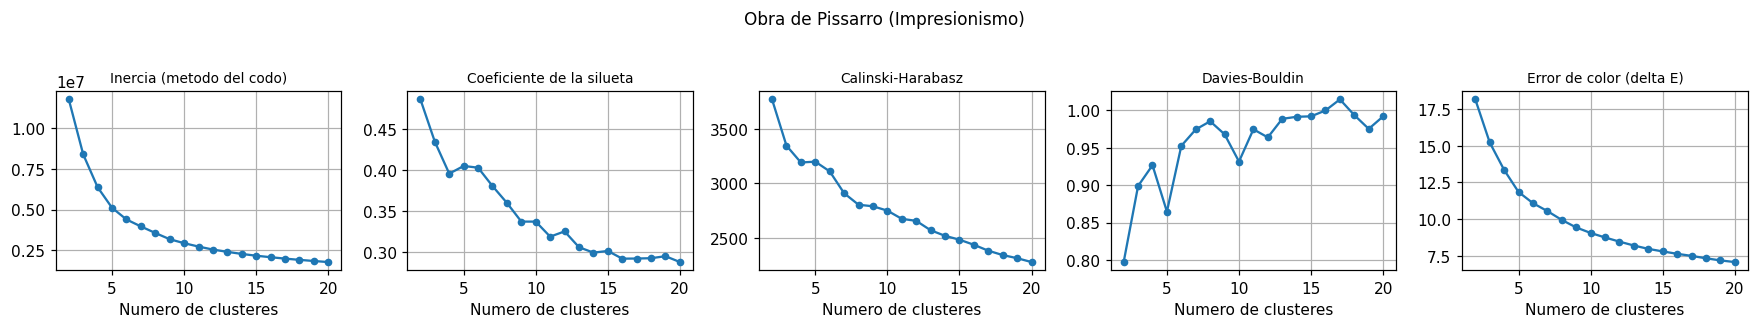

In [15]:
def plot_scores(scores, title=''):
    """
    Grafica las metricas de evaluacion contra el numero de clusteres.

    Parametros:
    scores : pd.DataFrame
        Tabla con las metricas devuelta por evaluate_k().
    title : str
        Titulo de la figura.
    """
    metricas = [('inercia', 'Inercia (metodo del codo)'),
                ('silueta', 'Coeficiente de la silueta'),
                ('calinski', 'Calinski-Harabasz'),
                ('davies', 'Davies-Bouldin'),
                ('delta_e', 'Error de color (delta E)')]

    plt.figure(figsize=(16, 3))
    for i, (col, nombre) in enumerate(metricas):
        plt.subplot(1, 5, i + 1)
        plt.plot(scores['k'], scores[col], marker='o', markersize=4)
        plt.title(nombre, fontsize=9)
        plt.xlabel('Numero de clusteres')
        plt.grid()

    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_scores(scores_pissarro, 'Obra de Pissarro (Impresionismo)')

Aquí encontramos un resultado que conviene analizar con cuidado. El coeficiente de la silueta y el
índice de Calinski-Harabasz alcanzan su mejor valor en `k = 2`, y Davies-Bouldin también prefiere
valores muy pequeños. Es decir, **las tres métricas nos dirían que la obra de Pissarro se representa
bien con solo dos colores**, lo cual no tiene sentido para una pintura impresionista.

La explicación es que estas métricas premian los grupos compactos y bien separados entre sí, y para
encontrarlos necesitan que existan zonas vacías entre los grupos. Sin embargo, la nube de colores de
una pintura es continua: los tonos van cambiando de forma gradual y no hay espacios vacíos que
separen unos de otros. Ante esta situación, la partición "más limpia" que las métricas pueden
encontrar es casi siempre la que separa la imagen en zonas claras y zonas oscuras, y por eso eligen
`k = 2` sin importar la obra.

El método del codo tampoco nos ayuda, porque la curva de la inercia desciende de forma suave y no
presenta un codo claro.

Comprobaremos que este comportamiento no es exclusivo de esta obra, calculando qué valor de `k`
elegiría el coeficiente de la silueta en cada una de las imágenes:

In [16]:
comparacion = []
todos_scores = {}
todos_models = {}

for i in range(len(img_files)):
    scores, models = evaluate_k(img_list[i])
    todos_scores[i] = scores
    todos_models[i] = models
    autor, estilo = get_info(img_files[i])
    comparacion.append({
        'autor': autor,
        'estilo': estilo,
        'k segun silueta': int(scores.loc[scores['silueta'].idxmax(), 'k']),
        'k segun calinski': int(scores.loc[scores['calinski'].idxmax(), 'k']),
        'k segun davies': int(scores.loc[scores['davies'].idxmin(), 'k']),
    })

pd.DataFrame(comparacion)

,autor,estilo,k segun silueta,k segun calinski,k segun davies
0,Albrecht Altdorfer,Renacimiento nordico,2,6,8
1,Andrea del Sarto,Alto Renacimiento italiano,3,6,3
2,Camille Pissarro,Impresionismo,2,2,2
3,Edward Hopper,Realismo estadounidense,3,5,3
4,Pablo Picasso,Postimpresionismo,4,5,4
5,Utagawa Kuniyoshi,Ukiyo-e (grabado japones),4,13,8
6,Vincent van Gogh,Postimpresionismo,2,4,3


La tabla confirma el problema, y de una forma más clara de lo que esperábamos. El coeficiente de la
silueta nunca se sale del rango de 2 a 4 grupos, sin importar de qué obra se trate. Pero lo más
revelador es el **orden** que producen: la obra de Pissarro, que es la más compleja del conjunto,
recibe el valor más pequeño posible en las tres métricas, mientras que el grabado de Kuniyoshi, hecho
con áreas planas de tinta, es de las que más grupos recibe.

Las métricas no solo prefieren valores pequeños, sino que ordenan las obras **al contrario** de lo que
indica su riqueza cromática. Si usáramos este criterio incumpliríamos el requisito del enunciado, que
pide que el número de grupos se ajuste a las características de cada imagen.

### Criterio adoptado: el error de color

Utilizaremos entonces la última métrica de la tabla, el **error de color**. Como estamos trabajando en
el espacio CIELab, la distancia entre un píxel y el centroide que lo representa es directamente la
diferencia de color que percibiría una persona; esta medida se conoce como *delta E*. Un valor de
delta E cercano a 2.3 corresponde a la mínima diferencia que el ojo humano alcanza a distinguir.

El criterio será entonces **elegir el menor `k` cuyo error de color medio no supere un umbral fijado**,
que en nuestro caso será `delta E = 8`. Dicho de otra forma, iremos añadiendo colores a la paleta
hasta que la imagen quede representada con suficiente fidelidad. La ventaja de este criterio es que se
adapta solo a cada obra: una imagen de áreas planas alcanza el umbral con pocos colores, mientras que
una de colores fragmentados necesita muchos más.

Elegimos el valor 8 y no 2.3 porque una paleta es un resumen de la obra, no una copia: exigir que no
se note ninguna diferencia produciría paletas de decenas de colores, que no servirían como referencia
de diseño. Por la misma razón limitamos la búsqueda a `k = 20` como máximo.

In [17]:
def select_k(scores, threshold=max_delta_e):
    """
    Retorna el menor k cuyo error de color no supera el umbral.

    Parametros:
    scores : pd.DataFrame
        Tabla con las metricas devuelta por evaluate_k().
    threshold : float
        Valor maximo admitido para el error de color.
    """
    validos = scores[scores['delta_e'] <= threshold]
    if len(validos) == 0:
        # Si ninguna opcion alcanza el umbral nos quedamos con el k mas grande
        return int(scores['k'].max())
    return int(validos['k'].min())


k_pissarro = select_k(scores_pissarro)
print('Numero de clusteres seleccionado para la obra de Pissarro:', k_pissarro)

Numero de clusteres seleccionado para la obra de Pissarro: 14


Aplicaremos el criterio a todas las obras para comprobar que el número de grupos efectivamente varía:

In [18]:
seleccion = []
for i in range(len(img_files)):
    autor, estilo = get_info(img_files[i])
    k = select_k(todos_scores[i])
    fila = todos_scores[i][todos_scores[i]['k'] == k].iloc[0]
    seleccion.append({
        'autor': autor,
        'estilo': estilo,
        'k': k,
        'delta_e': round(fila['delta_e'], 2),
        'silueta': round(fila['silueta'], 3),
        'davies': round(fila['davies'], 3),
    })

seleccion = pd.DataFrame(seleccion)
seleccion

,autor,estilo,k,delta_e,silueta,davies
0,Albrecht Altdorfer,Renacimiento nordico,5,7.83,0.357,0.943
1,Andrea del Sarto,Alto Renacimiento italiano,4,7.51,0.611,0.591
2,Camille Pissarro,Impresionismo,14,7.99,0.299,0.991
3,Edward Hopper,Realismo estadounidense,5,7.53,0.413,0.788
4,Pablo Picasso,Postimpresionismo,11,7.82,0.373,0.879
5,Utagawa Kuniyoshi,Ukiyo-e (grabado japones),10,7.71,0.379,0.825
6,Vincent van Gogh,Postimpresionismo,12,7.79,0.340,0.943


Ahora sí obtenemos un número de grupos distinto para cada obra, y además el resultado es coherente con
lo que esperábamos al seleccionar las imágenes: las obras renacentistas, pintadas con gamas
restringidas, necesitan pocos colores, mientras que la obra impresionista de Pissarro es la que más
colores requiere. Las métricas de silueta y Davies-Bouldin, que ya no usamos para elegir `k`, nos
sirven ahora para validar que las particiones obtenidas siguen siendo razonables.

## 5. Generación de la paleta de colores

Con el modelo entrenado ya podemos construir el muestrario. Definiremos la función `get_palette()`,
que toma los centroides encontrados por KMeans, los convierte de CIELab a RGB y los ordena de mayor a
menor según el porcentaje de la obra que ocupa cada uno. De esta forma la paleta refleja la jerarquía
real de los colores en el cuadro: primero los dominantes y después los de acento.

Añadiremos también el código hexadecimal de cada color, que es el formato que se usa habitualmente en
las herramientas de diseño:

In [19]:
def get_palette(X, model):
    """
    Genera el muestrario de colores a partir de los centroides del modelo.

    Parametros:
    X : np.array
        El arreglo con los pixeles de la imagen en CIELab.
    model : KMeans
        El modelo de agrupacion ya entrenado.
    """
    labels = model.predict(X)
    # Calculamos que porcentaje de la obra ocupa cada grupo
    counts = np.bincount(labels, minlength=model.n_clusters)
    proportions = counts / len(labels)

    # Ordenamos de mayor a menor presencia en la obra
    order = np.argsort(-proportions)
    centroids_lab = model.cluster_centers_[order]
    centroids_rgb = lab_to_rgb(centroids_lab)

    palette = pd.DataFrame({
        'color': range(1, len(order) + 1),
        'hex': ['#%02X%02X%02X' % tuple((c * 255).round().astype(int)) for c in centroids_rgb],
        'R': (centroids_rgb[:, 0] * 255).round().astype(int),
        'G': (centroids_rgb[:, 1] * 255).round().astype(int),
        'B': (centroids_rgb[:, 2] * 255).round().astype(int),
        'porcentaje': (proportions[order] * 100).round(2),
    })
    return palette, centroids_rgb

Para visualizar la paleta definiremos la función `plot_palette()`. Dibujaremos cada color como una
franja cuyo ancho es proporcional al porcentaje que ocupa en la obra, de manera que la barra funcione
como un resumen visual del cuadro:

In [20]:
def plot_palette(palette, colors_rgb, ax=None):
    """
    Dibuja el muestrario como una barra de franjas de color.

    Parametros:
    palette : pd.DataFrame
        Tabla con los colores devuelta por get_palette().
    colors_rgb : np.array
        Arreglo con los colores de la paleta en RGB.
    ax : matplotlib.axes.Axes
        Eje donde dibujar. Si es None se crea una figura nueva.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 1.5))

    inicio = 0
    for i in range(len(palette)):
        ancho = palette['porcentaje'][i] / 100
        ax.add_patch(plt.Rectangle((inicio, 0), ancho, 1, color=colors_rgb[i]))

        # Escribimos el codigo del color solo si la franja es suficientemente ancha
        if ancho > 0.06:
            # El texto va en blanco o negro segun que tan oscuro sea el fondo
            luminosidad = colors_rgb[i].mean()
            color_texto = 'white' if luminosidad < 0.5 else 'black'
            ax.text(inicio + ancho / 2, 0.5,
                    palette['hex'][i] + '\n' + str(palette['porcentaje'][i]) + '%',
                    ha='center', va='center', fontsize=7, color=color_texto)
        inicio = inicio + ancho

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

Probaremos las dos funciones con la obra de Pissarro:

,color,hex,R,G,B,porcentaje
0,1,#B7CAD3,183,202,211,10.40
1,2,#586727,88,103,39,9.49
2,3,#3F4327,63,67,39,8.81
3,4,#D7DFD7,215,223,215,8.76
4,5,#2C2C21,44,44,33,7.85
5,6,#99BADB,153,186,219,7.15
6,7,#848664,132,134,100,7.13
7,8,#879293,135,146,147,6.82
8,9,#5E5F59,94,95,89,6.49
9,10,#675E38,103,94,56,6.39


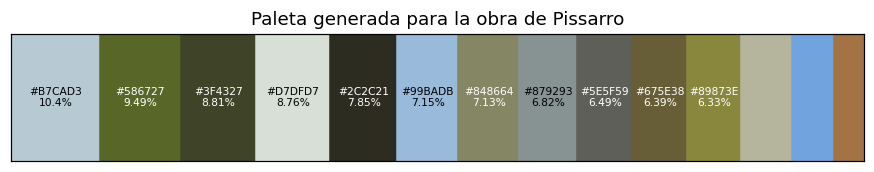

In [21]:
modelo_pissarro = models_pissarro[k_pissarro]
palette_pissarro, colors_pissarro = get_palette(img_list[idx_pissarro], modelo_pissarro)
display(palette_pissarro)

plot_palette(palette_pissarro, colors_pissarro)
plt.title('Paleta generada para la obra de Pissarro')
plt.show()

Podemos comprobar la calidad de la paleta reconstruyendo la imagen con los colores del muestrario, de
la misma forma que se hace en la práctica de segmentación con la expresión `centroids[labels]`. Si la
paleta representa bien la obra, la imagen reconstruida debe parecerse a la original:

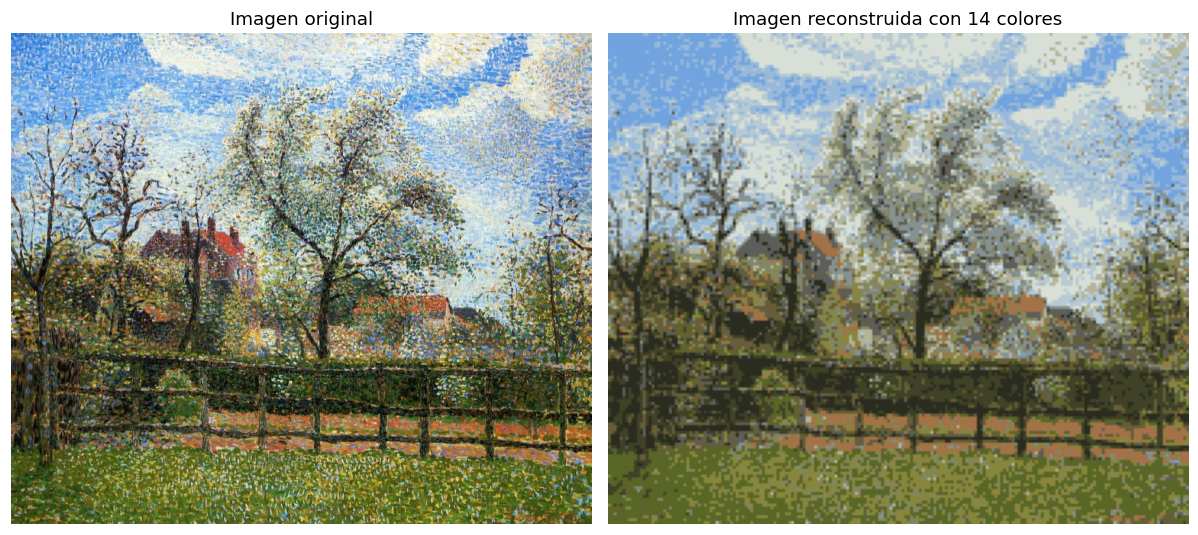

In [22]:
def segment_image(img, model):
    """
    Reconstruye la imagen reemplazando cada pixel por el color de su centroide.

    Parametros:
    img : np.array
        Arreglo de dimensiones (alto, ancho, 3) con la imagen original.
    model : KMeans
        El modelo de agrupacion ya entrenado.
    """
    img_small = resize_image(img)
    pixels_lab = rgb_to_lab(flatten_image(img_small))

    labels = model.predict(pixels_lab)
    centroids_rgb = lab_to_rgb(model.cluster_centers_)
    img_segmented = centroids_rgb[labels] * 255

    return img_segmented.reshape(img_small.shape).astype(np.uint8)


img_segmentada = segment_image(img_original[idx_pissarro], modelo_pissarro)

plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
plt.title('Imagen original')
plt.imshow(img_original[idx_pissarro])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Imagen reconstruida con {k_pissarro} colores')
plt.imshow(img_segmentada)
plt.axis('off')

plt.tight_layout()
plt.show()

## 6. Visualización de la distribución de colores con t-SNE

El enunciado pide mostrar la distribución de los colores de la imagen en un espacio de dos
dimensiones. Utilizaremos **t-SNE** siguiendo la sugerencia del enunciado, y además porque se ajusta
bien a lo que queremos observar: nos interesa saber qué colores forman agrupaciones vecinas y si esas
agrupaciones se separan entre sí, que es justamente la estructura local que t-SNE conserva. Si
usáramos PCA, al buscar la mayor varianza la proyección quedaría dominada por el eje de la
luminosidad y se superpondrían colores distintos con luminosidad parecida.

Debemos tener en cuenta al interpretar el resultado que en un gráfico de t-SNE las distancias entre
los grupos y sus tamaños no son significativas; solo podemos interpretar qué puntos quedan cerca de
cuáles. Usaremos una muestra de 2500 píxeles porque el costo del algoritmo crece muy rápido con el
número de datos:

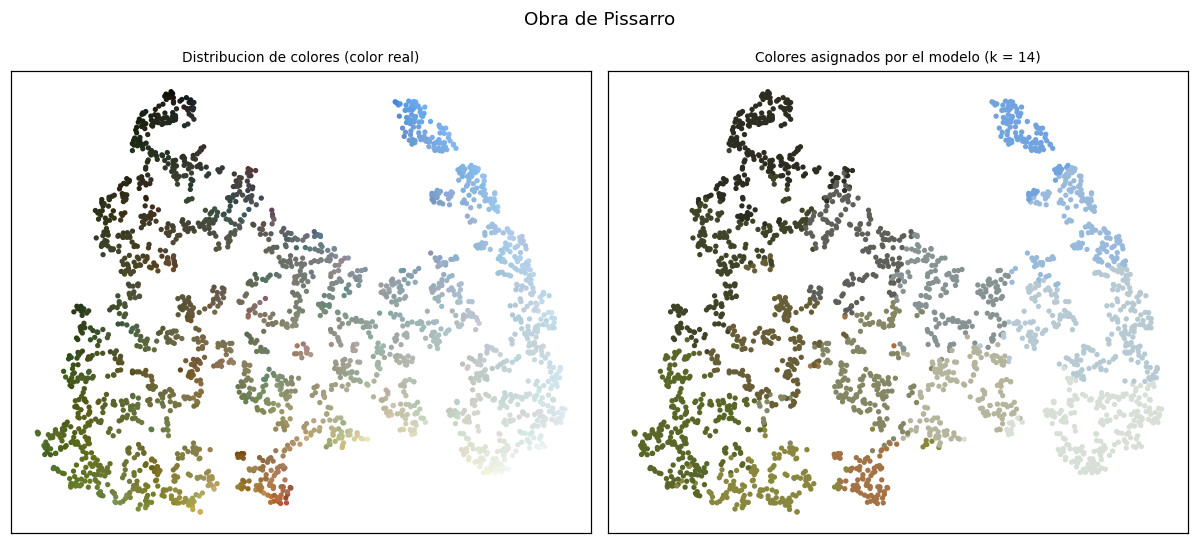

In [23]:
def plot_tsne(X, model, ax_real=None, ax_group=None):
    """
    Proyecta los colores de la imagen a dos dimensiones con t-SNE.

    Parametros:
    X : np.array
        El arreglo con los pixeles de la imagen en CIELab.
    model : KMeans
        El modelo de agrupacion ya entrenado.
    ax_real, ax_group : matplotlib.axes.Axes
        Ejes donde dibujar. Si son None se crea una figura nueva.
    """
    idx = np.random.RandomState(random_state).choice(
        len(X), min(n_sample_tsne, len(X)), replace=False)
    X_sample = X[idx]

    tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=random_state)
    coords = tsne.fit_transform(X_sample)

    # Color real de cada pixel y color del grupo al que fue asignado
    colors_real = lab_to_rgb(X_sample)
    labels = model.predict(X_sample)
    colors_group = lab_to_rgb(model.cluster_centers_)[labels]

    if ax_real is None:
        fig, (ax_real, ax_group) = plt.subplots(1, 2, figsize=(11, 5))

    ax_real.scatter(coords[:, 0], coords[:, 1], c=colors_real, s=6)
    ax_real.set_title('Distribucion de colores (color real)', fontsize=9)

    ax_group.scatter(coords[:, 0], coords[:, 1], c=colors_group, s=6)
    ax_group.set_title(f'Colores asignados por el modelo (k = {model.n_clusters})', fontsize=9)

    for ax in (ax_real, ax_group):
        ax.set_xticks([])
        ax.set_yticks([])

    return ax_real, ax_group


plot_tsne(img_list[idx_pissarro], modelo_pissarro)
plt.suptitle('Obra de Pissarro')
plt.tight_layout()
plt.show()

En el gráfico de la izquierda cada punto conserva su color real y en el de la derecha toma el color
del grupo que le asignó el modelo. Al comparar los dos podemos evaluar visualmente la calidad de la
agrupación: si la paleta representa bien la obra, ambos gráficos deben verse muy parecidos.

## 7. Resultados para todas las imágenes

Reuniremos todo el método en una sola función que, dada una imagen, ejecute la preparación, la
selección del número de grupos, la generación de la paleta y la visualización:

In [24]:
def show_result(i):
    """
    Muestra el resultado completo del metodo para una obra.

    Parametros:
    i : int
        Indice de la obra dentro de la lista img_files.
    """
    autor, estilo = get_info(img_files[i])
    k = select_k(todos_scores[i])
    model = todos_models[i][k]
    palette, colors_rgb = get_palette(img_list[i], model)

    fig = plt.figure(figsize=(14, 6.5))

    # Imagen original
    ax1 = plt.subplot2grid((3, 3), (0, 0), rowspan=2)
    ax1.imshow(img_original[i])
    ax1.set_title('Imagen original', fontsize=9)
    ax1.axis('off')

    # Proyeccion con t-SNE
    ax2 = plt.subplot2grid((3, 3), (0, 1), rowspan=2)
    ax3 = plt.subplot2grid((3, 3), (0, 2), rowspan=2)
    plot_tsne(img_list[i], model, ax2, ax3)

    # Paleta generada
    ax4 = plt.subplot2grid((3, 3), (2, 0), colspan=3)
    plot_palette(palette, colors_rgb, ax4)
    ax4.set_title('Paleta generada (el ancho indica el porcentaje de la obra)', fontsize=9)

    plt.suptitle(f'{autor} - {estilo} (k = {k})', fontsize=12)
    plt.tight_layout()
    plt.show()

    display(palette)

A continuación mostramos el resultado para las siete obras del conjunto:

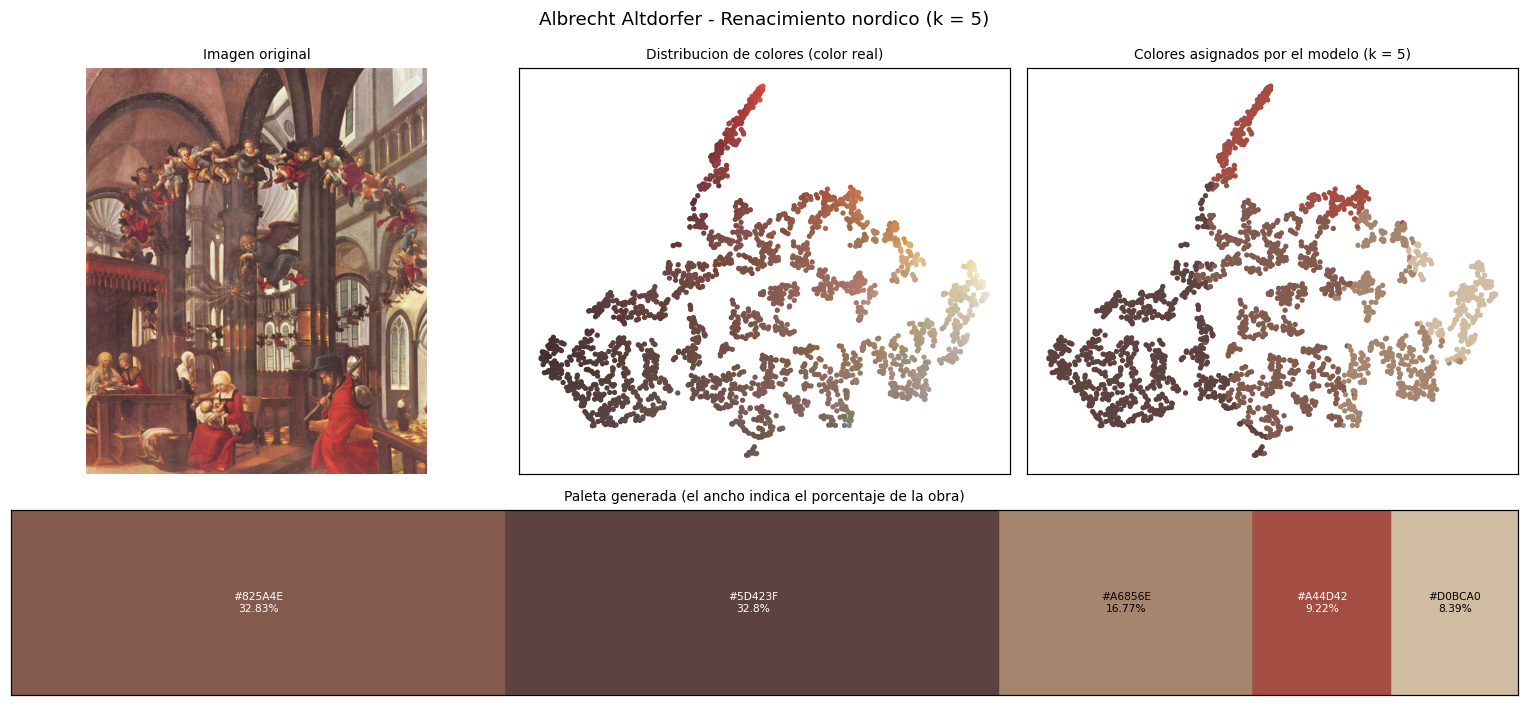

,color,hex,R,G,B,porcentaje
0,1,#825A4E,130,90,78,32.83
1,2,#5D423F,93,66,63,32.80
2,3,#A6856E,166,133,110,16.77
3,4,#A44D42,164,77,66,9.22
4,5,#D0BCA0,208,188,160,8.39


In [25]:
show_result(0)

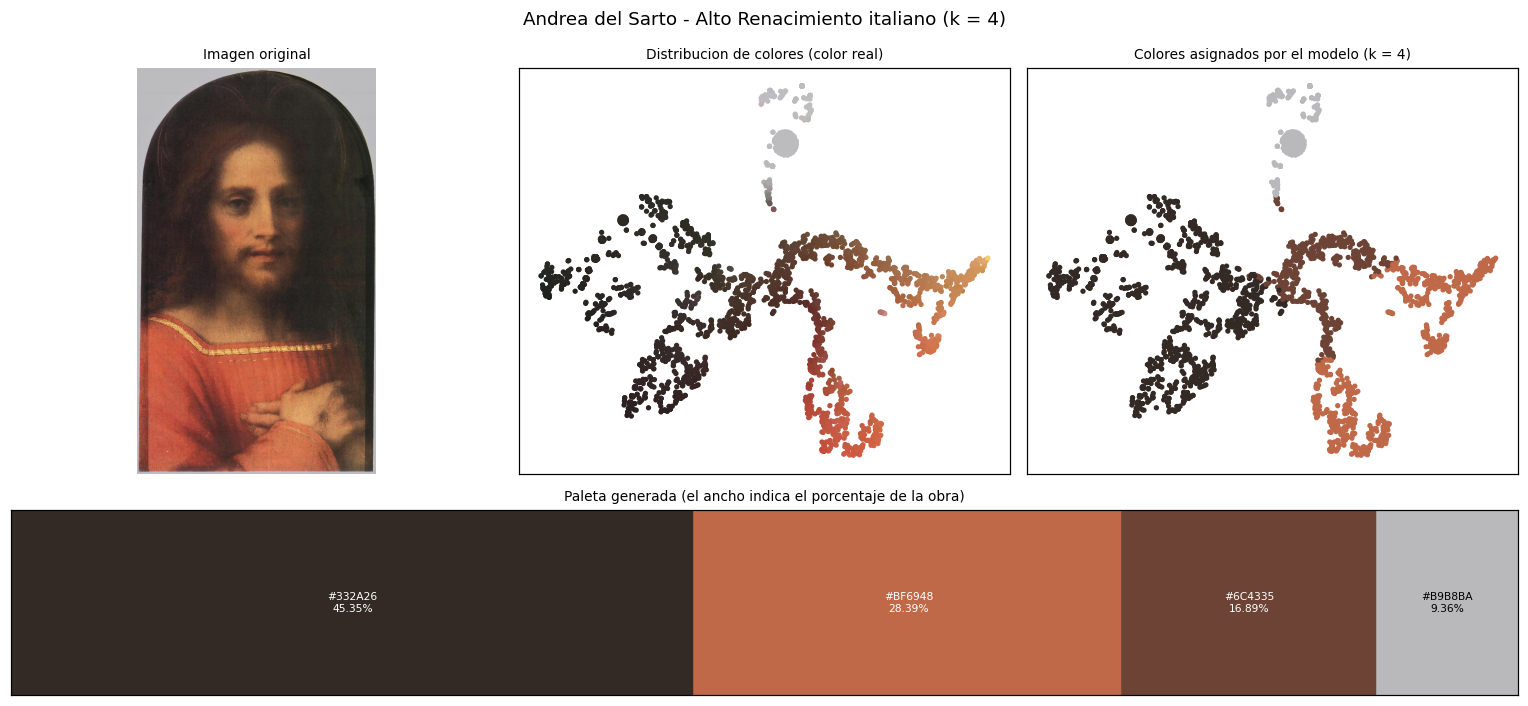

,color,hex,R,G,B,porcentaje
0,1,#332A26,51,42,38,45.35
1,2,#BF6948,191,105,72,28.39
2,3,#6C4335,108,67,53,16.89
3,4,#B9B8BA,185,184,186,9.36


In [26]:
show_result(1)

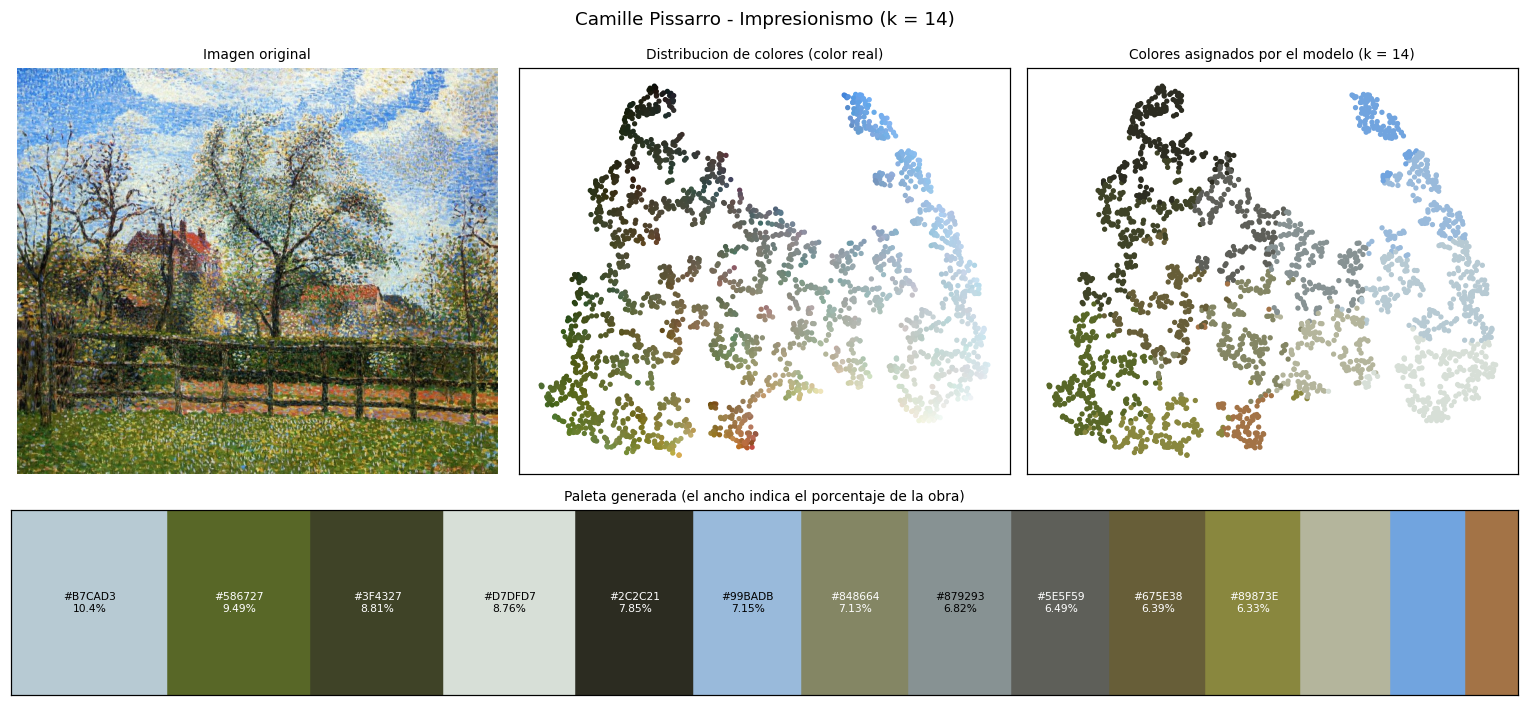

,color,hex,R,G,B,porcentaje
0,1,#B7CAD3,183,202,211,10.40
1,2,#586727,88,103,39,9.49
2,3,#3F4327,63,67,39,8.81
3,4,#D7DFD7,215,223,215,8.76
4,5,#2C2C21,44,44,33,7.85
5,6,#99BADB,153,186,219,7.15
6,7,#848664,132,134,100,7.13
7,8,#879293,135,146,147,6.82
8,9,#5E5F59,94,95,89,6.49
9,10,#675E38,103,94,56,6.39


In [27]:
show_result(2)

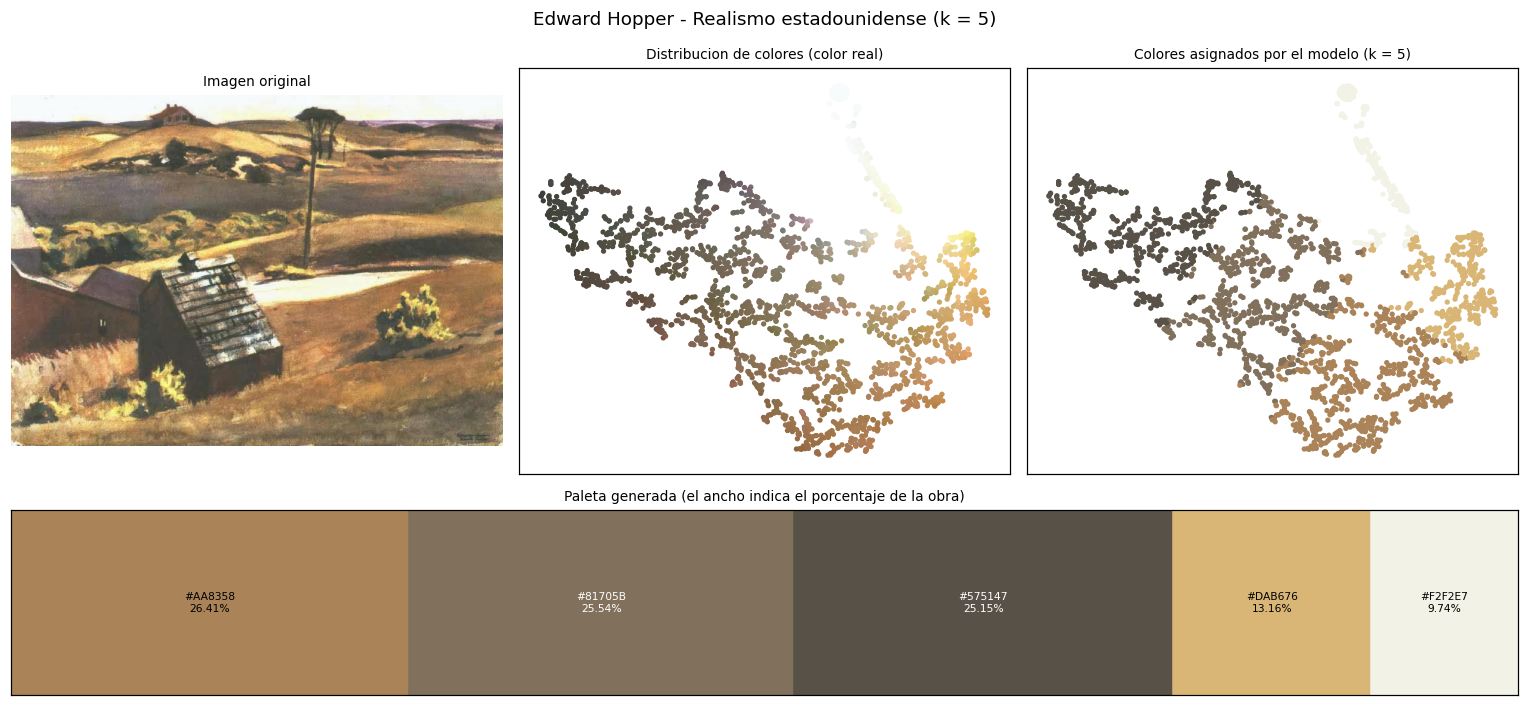

,color,hex,R,G,B,porcentaje
0,1,#AA8358,170,131,88,26.41
1,2,#81705B,129,112,91,25.54
2,3,#575147,87,81,71,25.15
3,4,#DAB676,218,182,118,13.16
4,5,#F2F2E7,242,242,231,9.74


In [28]:
show_result(3)

In [ ]:
show_result(4)

In [ ]:
show_result(5)

In [ ]:
show_result(6)

Finalmente, reuniremos todas las paletas en una sola figura para poder compararlas:

In [ ]:
fig, axes = plt.subplots(len(img_files), 1, figsize=(11, 1.3 * len(img_files)))

for i in range(len(img_files)):
    k = select_k(todos_scores[i])
    model = todos_models[i][k]
    palette, colors_rgb = get_palette(img_list[i], model)
    plot_palette(palette, colors_rgb, axes[i])

    autor, estilo = get_info(img_files[i])
    axes[i].set_ylabel(f'{autor}\n(k = {k})', rotation=0, ha='right', va='center', fontsize=8)

plt.suptitle('Paletas generadas para todas las obras', fontsize=12)
plt.tight_layout()
plt.show()

## Cierre

En este notebook desarrollamos un método para generar paletas de colores a partir de imágenes usando
el algoritmo KMeans. En particular, construimos un pipeline de preparación que redimensiona las
imágenes y convierte sus píxeles al espacio CIELab, seleccionamos el número de clústeres de forma
independiente para cada obra y transformamos los grupos resultantes en un muestrario ordenado por la
presencia de cada color, acompañado de la visualización de la distribución de colores con t-SNE.

Los dos resultados que consideramos más importantes son los siguientes:

**Trabajar en CIELab en lugar de RGB.** Como KMeans agrupa usando la distancia euclidiana, el espacio
de color define qué significa que dos colores se parezcan. En CIELab esa distancia se aproxima a la
diferencia que percibe el ojo, por lo que los grupos coinciden mejor con lo que reconocemos como un
mismo tono.

**Las métricas internas no sirven para elegir k en este problema.** El coeficiente de la silueta se
mantuvo siempre entre 2 y 4 grupos, y las tres métricas ordenaron las obras de forma contraria a su
riqueza cromática: a la obra impresionista, la más compleja del conjunto, le asignaron el menor número
de grupos posible. Esto ocurre porque estas métricas buscan grupos separados por zonas vacías, y la
nube de colores de una pintura es continua. Al reemplazarlas por una cota al error de color
obtuvimos un número de grupos que sí varía de acuerdo con el estilo de cada obra, tal como pedía el
enunciado. Las métricas internas las conservamos para validar que las particiones obtenidas siguen
siendo razonables.

Ten en cuenta que el procesamiento y el algoritmo utilizados no son los únicos que pueden dar solución
a este problema. Entre las limitaciones del método está que se descarta por completo la información
espacial, de modo que dos obras con los mismos colores distribuidos de forma distinta producirían la
misma paleta; que KMeans tiende a absorber los colores de acento poco frecuentes dentro de grupos más
grandes; y que el método identifica los colores dominantes pero no evalúa la armonía entre ellos, que
sería el paso siguiente para construir una herramienta de diseño completa.